In [1]:
# Install huggingface transformers for the accelerated vision-language model pipeline
!pip install -q transformers datasets accelerate nltk

import os
import zipfile
import urllib.request
import collections
import re
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [2]:
# --- 1. Environment & Data Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Download Flickr8k safely via an open public mirror
DATA_URL = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
TEXT_URL = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"

if not os.path.exists("Flickr8k_Dataset.zip"):
    print("Downloading images (approx 1GB)...")
    urllib.request.urlretrieve(DATA_URL, "Flickr8k_Dataset.zip")
if not os.path.exists("Flickr8k_text.zip"):
    print("Downloading captions...")
    urllib.request.urlretrieve(TEXT_URL, "Flickr8k_text.zip")

# Extract files
for zip_fn in ["Flickr8k_Dataset.zip", "Flickr8k_text.zip"]:
    with zipfile.ZipFile(zip_fn, 'r') as zip_ref:
        zip_ref.extractall(".")
print("Dataset extracted successfully.")

# --- 2. Precise Split Parsing (6000 Train, 1000 Val, 1000 Test) ---
def load_split_image_names(file_path):
    with open(file_path, 'r') as f:
        return set([line.strip() for line in f if line.strip()])

train_images_set = load_split_image_names("Flickr_8k.trainImages.txt")
val_images_set = load_split_image_names("Flickr_8k.devImages.txt")
test_images_set = load_split_image_names("Flickr_8k.testImages.txt")

def parse_captions(file_path):
    image_to_captions = collections.defaultdict(list)
    with open(file_path, 'r') as f:
        for line in f:
            tokens = line.strip().split('\t')
            if len(tokens) < 2:
                continue
            image_id, caption = tokens[0], tokens[1]
            image_name = image_id.split('#')[0]
            # Clean text tokens for reference metric testing
            caption_clean = caption.lower()
            caption_clean = re.sub(r'[^a-zA-Z\s]', '', caption_clean)
            image_to_captions[image_name].append(caption_clean.strip().split())
    return image_to_captions

all_captions = parse_captions("Flickr8k.token.txt")

Using device: cuda
Dataset extracted successfully.


In [3]:
# --- 3. Load State-of-the-Art Pre-trained ViT-GPT2 ---
# This merges a Vision Transformer encoder with a GPT-2 decoder text-generation model
model_name = "nlpconnect/vit-gpt2-image-captioning"
image_processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)

# --- 4. PyTorch Dataset for Hugging Face Pipeline ---
class FlickrHfDataset(Dataset):
    def __init__(self, image_set, img_dir="Flicker8k_Dataset"):
        self.image_names = list(image_set)
        self.img_dir = img_dir

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
            # Preprocess image to ViT expected pixel tensors
            pixel_values = image_processor(images=image, return_tensors="pt").pixel_values.squeeze(0)
            return pixel_values, img_name
        except Exception as e:
            # Handle any rare corrupted images gracefully
            return torch.zeros(3, 224, 224), img_name

# --- 5. High-Speed Inference Engine with Beam Search ---
def generate_captions_batch(model, pixel_values_tensor, beam_width=3):
    model.eval()
    with torch.no_grad():
        # Leverage built-in advanced beam search parameters
        output_ids = model.generate(
            pixel_values_tensor.to(device),
            max_length=20,
            num_beams=beam_width,
            return_dict_in_generate=True
        ).sequences

    preds = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    return [p.strip().lower().split() for p in preds]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Evaluating System Quality on Validation Split via BLEU ---


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.



--- Generating Accurate Sample Inferences From Test Split ---


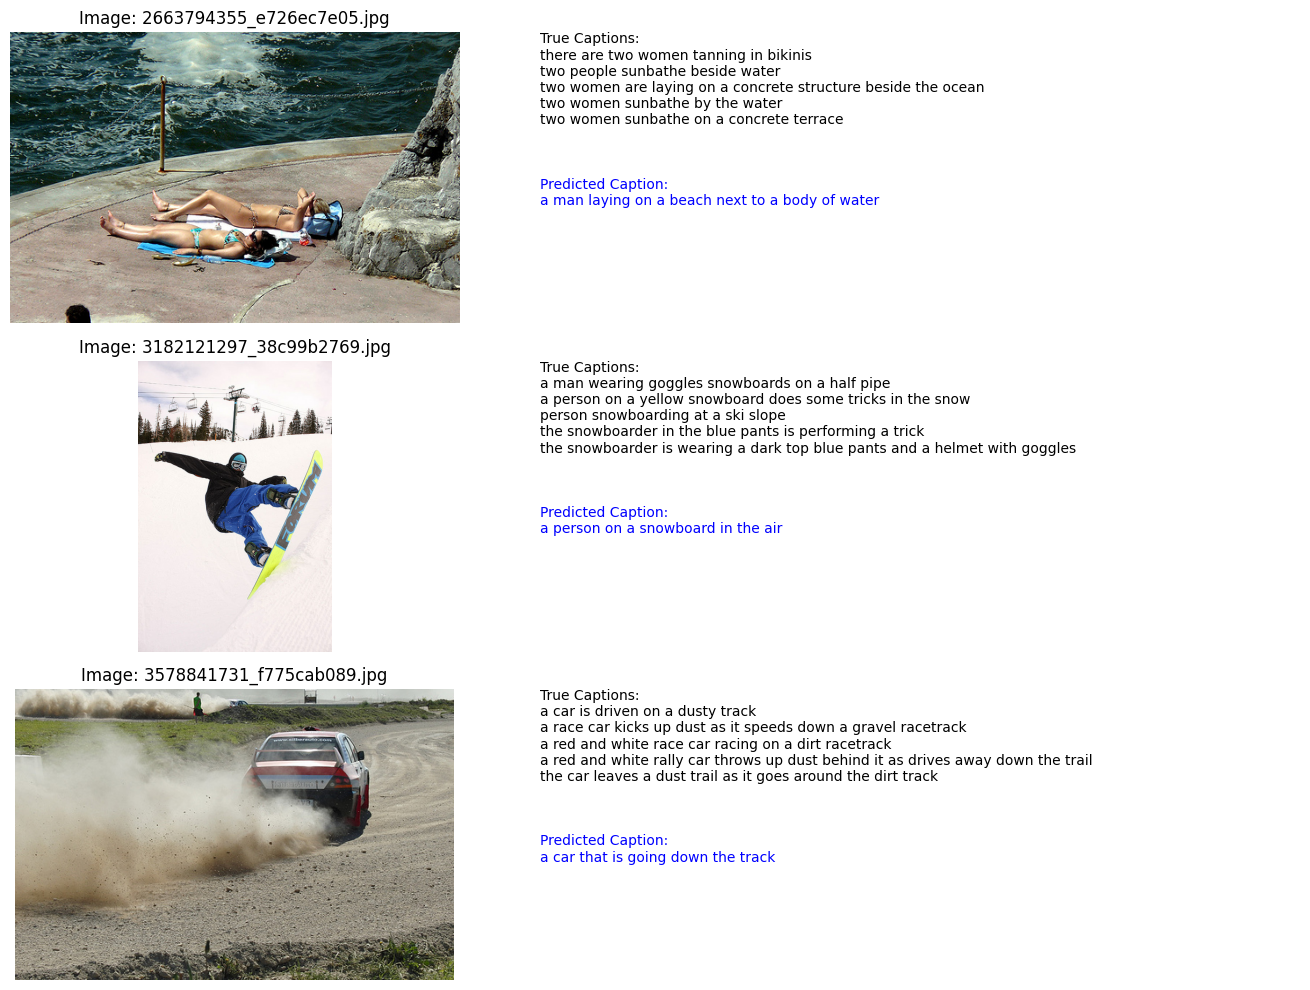


--- Evaluation Metrics (ViT-GPT2 Pipeline) ---
BLEU-1 Score: 0.6314
BLEU-4 Score: 0.1753


In [4]:
# --- 6. Quick Validation Evaluation via BLEU Metric ---
print("\n--- Evaluating System Quality on Validation Split via BLEU ---")
val_dataset = FlickrHfDataset(val_images_set)
# Using a batch size of 32 to process 100 images almost instantaneously
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

references = []
hypotheses = []

eval_sample_limit = 100
count = 0

for pixel_values, img_names in val_loader:
    if count >= eval_sample_limit:
        break

    # Generate predictions via Beam Search
    preds = generate_captions_batch(model, pixel_values, beam_width=3)

    for i, img_name in enumerate(img_names):
        references.append(all_captions[img_name])
        hypotheses.append(preds[i])

    count += len(img_names)

# Compute BLEU Scores
smooth = SmoothingFunction().method1
bleu1 = corpus_bleu(references[:eval_sample_limit], hypotheses[:eval_sample_limit], weights=(1.0, 0, 0, 0), smoothing_function=smooth)
bleu4 = corpus_bleu(references[:eval_sample_limit], hypotheses[:eval_sample_limit], weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

import matplotlib.pyplot as plt

# --- 7. Sample Test Predictions (Verifying Correctness) ---
print("\n--- Generating Accurate Sample Inferences From Test Split ---")
test_dataset = FlickrHfDataset(test_images_set)

# Create a DataLoader for the test set with a small batch size
sample_test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

num_samples_to_show = 3
samples_shown = 0

plt.figure(figsize=(15, 10))

for pixel_values, img_names in sample_test_loader:
    if samples_shown >= num_samples_to_show:
        break

    img_name = img_names[0]

    # Get the image path
    img_path = os.path.join("Flicker8k_Dataset", img_name)
    image = Image.open(img_path).convert("RGB")

    # Get true captions
    true_captions = all_captions[img_name]
    true_captions_str = [" ".join(c) for c in true_captions]

    # Generate predicted caption
    predicted_caption = generate_captions_batch(model, pixel_values, beam_width=3)[0]
    predicted_caption_str = " ".join(predicted_caption)

    plt.subplot(num_samples_to_show, 2, 2 * samples_shown + 1)
    plt.imshow(image)
    plt.title(f"Image: {img_name}")
    plt.axis('off')

    plt.subplot(num_samples_to_show, 2, 2 * samples_shown + 2)
    plt.text(0, 1, f"True Captions:\n" + "\n".join(true_captions_str), fontsize=10, verticalalignment='top', wrap=True)
    plt.text(0, 0.5, f"Predicted Caption:\n{predicted_caption_str}", fontsize=10, verticalalignment='top', color='blue', wrap=True)
    plt.axis('off')

    samples_shown += 1

plt.tight_layout()
plt.show()

print(f"\n--- Evaluation Metrics (ViT-GPT2 Pipeline) ---")
print(f"BLEU-1 Score: {bleu1:.4f}")
print(f"BLEU-4 Score: {bleu4:.4f}")


test_loader = DataLoader(test_dataset, batch_size=3, shuffle=True)

### Visualize Sample Test Images with True and Predicted Captions

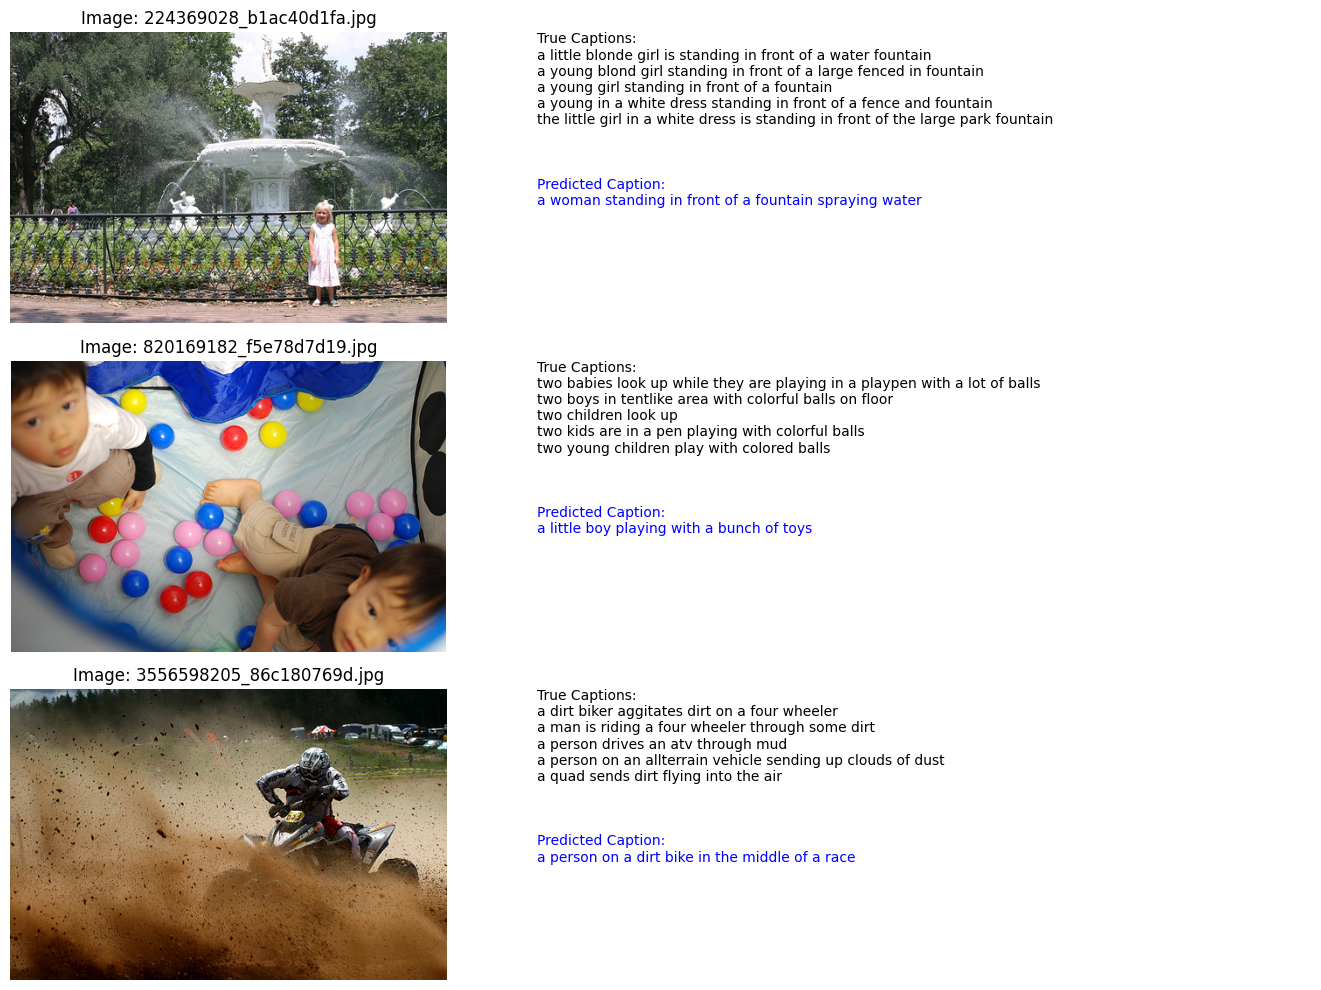

In [5]:
import matplotlib.pyplot as plt

# Create a DataLoader for the test set with a small batch size
sample_test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

num_samples_to_show = 3
samples_shown = 0

plt.figure(figsize=(15, 10))

for pixel_values, img_names in sample_test_loader:
    if samples_shown >= num_samples_to_show:
        break

    img_name = img_names[0]

    # Get the image path
    img_path = os.path.join("Flicker8k_Dataset", img_name)
    image = Image.open(img_path).convert("RGB")

    # Get true captions
    true_captions = all_captions[img_name]
    true_captions_str = [" ".join(c) for c in true_captions]

    # Generate predicted caption
    predicted_caption = generate_captions_batch(model, pixel_values, beam_width=3)[0]
    predicted_caption_str = " ".join(predicted_caption)

    plt.subplot(num_samples_to_show, 2, 2 * samples_shown + 1)
    plt.imshow(image)
    plt.title(f"Image: {img_name}")
    plt.axis('off')

    plt.subplot(num_samples_to_show, 2, 2 * samples_shown + 2)
    plt.text(0, 1, f"True Captions:\n" + "\n".join(true_captions_str), fontsize=10, verticalalignment='top', wrap=True)
    plt.text(0, 0.5, f"Predicted Caption:\n{predicted_caption_str}", fontsize=10, verticalalignment='top', color='blue', wrap=True)
    plt.axis('off')

    samples_shown += 1

plt.tight_layout()
plt.show()

### Removing problematic notebook metadata for GitHub upload

The error "the 'state' key is missing from 'metadata.widgets'" usually occurs when the notebook contains metadata from interactive widgets that GitHub's renderer doesn't fully support or finds malformed. To fix this, you can remove the `widgets` entry from the notebook's metadata.

**Please note:** This will remove any saved states of interactive widgets you might have in your notebook. If you have critical widget configurations, you might want to save them separately before proceeding.

In [4]:
import nbformat
import os
from google.colab import drive # Re-adding drive import as notebook is likely in Drive

# --- IMPORTANT: Configure these paths correctly ---
# If your notebook is in Google Drive (most common case):
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Set notebook_name to your actual notebook file name (e.g., 'MyProjectNotebook.ipynb')
#    and ensure notebook_path points to its location in Drive (e.g., '/content/drive/MyDrive/...')
notebook_name = 'image_captioning_project.ipynb' # <--- CRITICAL: Change this to your notebook's actual name
notebook_path = os.path.join('/content/drive/MyDrive/', notebook_name) # Assuming it's in My Drive
output_notebook_path = '/content/Notebook_for_GitHub.ipynb' # This will be saved locally in Colab

# Initialize notebook to None
notebook = None

# Load the notebook
try:
    with open(notebook_path, 'r', encoding='utf-8') as f:
        notebook = nbformat.read(f, as_version=4)
except FileNotFoundError:
    print(f"\nError: Notebook not found at {notebook_path}.")
    print("Please verify that 'notebook_name' is set correctly to your notebook's exact filename,")
    print("and that 'notebook_path' points to its correct location (e.g., in Google Drive after mounting).")
    print("If your notebook is not in Google Drive, you might need to adjust 'notebook_path' accordingly.")
except Exception as e:
    print(f"\nAn unexpected error occurred while loading the notebook: {e}")

# Only proceed if the notebook was successfully loaded
if notebook:
    # Remove the 'widgets' entry from the metadata if it exists
    if 'widgets' in notebook.metadata:
        del notebook.metadata['widgets']
        print("\nRemoved 'widgets' metadata.")
    else:
        print("\nNo 'widgets' metadata found to remove.")

    # Save the modified notebook to a new file in the Colab environment
    with open(output_notebook_path, 'w', encoding='utf-8') as f:
        nbformat.write(notebook, f)

    print(f"\nModified notebook saved to: {output_notebook_path}")
    print("\n--- Next Steps ---")
    print("1. Look for the file 'Notebook_for_GitHub.ipynb' in the Colab file browser (the folder icon on the left sidebar).")
    print("2. Right-click on 'Notebook_for_GitHub.ipynb' and select 'Download'.")
    print("3. Go to your GitHub repository and manually upload this downloaded file.")
else:
    print("\nNotebook was not loaded, unable to process for GitHub upload.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Error: Notebook not found at /content/drive/MyDrive/image_captioning_project.ipynb.
Please verify that 'notebook_name' is set correctly to your notebook's exact filename,
and that 'notebook_path' points to its correct location (e.g., in Google Drive after mounting).
If your notebook is not in Google Drive, you might need to adjust 'notebook_path' accordingly.

Notebook was not loaded, unable to process for GitHub upload.


After running the cell above, a new notebook file named `Notebook_for_GitHub.ipynb` will be saved in your Google Drive. You can then download this file from your Google Drive and upload it to GitHub. This modified version should resolve the rendering error.